Mount Drive & Import Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/sentiment-robustness-id/src')
from config import *

print(f'ROOT: {ROOT}')
print('✅ Config loaded')

Mounted at /content/drive
ROOT: /content/drive/MyDrive/sentiment-robustness-id
✅ Config loaded


Import Library

In [2]:
import pandas as pd
import numpy as np
import random
import re
import os
from copy import deepcopy
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from typing import List, Tuple, Dict, Callable
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = RANDOM_STATE
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Library siap')

✅ Library siap


Load Test Set

In [3]:
df_all  = pd.read_csv(PROCESSED_DATA_PATH)
df_test = df_all[df_all['split'] == 'test'].copy().reset_index(drop=True)

print('=== TEST SET INFO ===')
print(f'Total baris   : {len(df_test):,}')
print(f'Kolom         : {df_test.columns.tolist()}')
print(f'\nDistribusi label:')
for label_id, count in df_test[LABEL_COLUMN].value_counts().sort_index().items():
    print(f'  {LABEL_MAP[label_id]:10s}: {count:,} ({count/len(df_test)*100:.1f}%)')

print(f'\nContoh teks:')
for i, row in df_test.head(3).iterrows():
    print(f'  [{LABEL_MAP[row[LABEL_COLUMN]]}] {row["tweet_clean"][:80]}')

=== TEST SET INFO ===
Total baris   : 3,495
Kolom         : ['tweet_clean', 'sentiment', 'split']

Distribusi label:
  Negatif   : 291 (8.3%)
  Positif   : 2,613 (74.8%)
  Netral    : 591 (16.9%)

Contoh teks:
  [Positif] ppkm versiku pakai smartfren gokil max karena anti lelet dan bisa dipakai 24jam 
  [Positif] mari tetap disiplin prokes meski sudah divaksin covid bersatulawancovid19 ppkm n
  [Positif] britishgp f1 ppkmdaruratberdampakbaik ppkm


Definisi Peta Noise Khas Bahasa Indonesia

In [4]:
# ============================================================
# NOISE PATTERN REGISTRY
# Setiap kategori noise merepresentasikan fenomena linguistik
# yang umum ditemukan pada teks informal Bahasa Indonesia
# ============================================================

# 1. SUBSTITUSI KARAKTER — penggantian huruf dengan karakter serupa
#    Contoh: bagus → baguz, tidak → tydak
CHAR_SUBSTITUTION_MAP: Dict[str, List[str]] = {
    'a': ['4', '@', 'q'],
    'e': ['3', 'eh'],
    'i': ['1', 'y', '!'],
    'o': ['0', 'u'],
    'u': ['v', 'uw'],
    's': ['z', '5'],
    'g': ['9', 'q'],
    'k': ['q', 'c'],
    'n': ['m', 'ng'],
    't': ['7', 'th'],
}

# 2. PENGHILANGAN VOKAL — common pada singkatan informal
#    Contoh: mantap → mntp, keren → krn, banget → bngt
VOWELS = set('aiueo')

# 3. SLANG & SINGKATAN KHAS INDONESIA
#    Pemetaan dari kata formal ke informal/slang
SLANG_MAP: Dict[str, List[str]] = {
    'tidak'   : ['gak', 'ga', 'gk', 'nggak', 'enggak', 'ndak'],
    'kamu'    : ['km', 'lo', 'elu', 'loe'],
    'saya'    : ['gue', 'gw', 'aku', 'w'],
    'sangat'  : ['bgt', 'banget', 'poll', 'parah'],
    'dengan'  : ['dgn', 'ama', 'sama'],
    'yang'    : ['yg', 'yng'],
    'sudah'   : ['udah', 'udh', 'dah'],
    'belum'   : ['blm', 'blom', 'belom'],
    'karena'  : ['krn', 'karna', 'soalnya'],
    'mereka'  : ['mrk', 'mereka'],
    'juga'    : ['jg', 'jugak', 'pun'],
    'tapi'    : ['tp', 'tpi', 'tapii'],
    'untuk'   : ['utk', 'buat', 'bwt'],
    'kalau'   : ['klo', 'kalo', 'klw'],
    'bagus'   : ['oke', 'ok', 'mantap', 'mantul', 'mantab'],
    'jelek'   : ['parah', 'ancur', 'rusak', 'boo'],
    'bisa'    : ['bs', 'bsa', 'iso'],
    'mau'     : ['mo', 'mw', 'pengen'],
    'ada'     : ['ad', 'ade'],
    'apa'     : ['ap', 'apaan', 'apasih'],
}

# 4. REPETISI KARAKTER BERLEBIHAN — penekanan emosional
#    Contoh: bagus → baguuuus, parah → parahhhhh
REPETITION_CHARS   = list('aiueoknrsh')
REPETITION_MIN     = 2
REPETITION_MAX     = 4

# 5. KEYBOARD PROXIMITY ERROR — salah ketik karena posisi keyboard QWERTY
#    Contoh: makan → majan, suka → suja
KEYBOARD_PROXIMITY_MAP: Dict[str, List[str]] = {
    'q': ['w', 'a'],        'w': ['q', 'e', 'a', 's'],
    'e': ['w', 'r', 's', 'd'], 'r': ['e', 't', 'd', 'f'],
    't': ['r', 'y', 'f', 'g'], 'y': ['t', 'u', 'g', 'h'],
    'u': ['y', 'i', 'h', 'j'], 'i': ['u', 'o', 'j', 'k'],
    'o': ['i', 'p', 'k', 'l'], 'p': ['o', 'l'],
    'a': ['q', 'w', 's', 'z'], 's': ['a', 'w', 'e', 'd', 'z', 'x'],
    'd': ['s', 'e', 'r', 'f', 'x', 'c'], 'f': ['d', 'r', 't', 'g', 'c', 'v'],
    'g': ['f', 't', 'y', 'h', 'v', 'b'], 'h': ['g', 'y', 'u', 'j', 'b', 'n'],
    'j': ['h', 'u', 'i', 'k', 'n', 'm'], 'k': ['j', 'i', 'o', 'l', 'm'],
    'l': ['k', 'o', 'p'],   'z': ['a', 's', 'x'],
    'x': ['z', 's', 'd', 'c'], 'c': ['x', 'd', 'f', 'v'],
    'v': ['c', 'f', 'g', 'b'], 'b': ['v', 'g', 'h', 'n'],
    'n': ['b', 'h', 'j', 'm'], 'm': ['n', 'j', 'k'],
}

# 6. PENGHAPUSAN KARAKTER ACAK — simulasi ketik terburu-buru
#    Contoh: sekarang → skrng, tolong → tlng

print('✅ Noise pattern registry didefinisikan')
print(f'   Char substitution  : {len(CHAR_SUBSTITUTION_MAP)} karakter terdaftar')
print(f'   Slang map          : {len(SLANG_MAP)} kata terdaftar')
print(f'   Keyboard proximity : {len(KEYBOARD_PROXIMITY_MAP)} karakter terdaftar')

✅ Noise pattern registry didefinisikan
   Char substitution  : 10 karakter terdaftar
   Slang map          : 20 kata terdaftar
   Keyboard proximity : 26 karakter terdaftar


Implementasi Fungsi Noise Per Kategori

In [5]:
# ============================================================
# NOISE FUNCTIONS
# Setiap fungsi menerima satu kata (token) dan
# mengembalikan versi noise-nya
# ============================================================

def apply_char_substitution(word: str) -> str:
    """
    Ganti satu karakter dalam kata dengan karakter serupa.
    Contoh: bagus → baguz, tidak → tydak
    """
    chars = list(word)
    # Temukan posisi yang bisa disubstitusi
    candidates = [
        (i, c) for i, c in enumerate(chars)
        if c in CHAR_SUBSTITUTION_MAP
    ]
    if not candidates:
        return word
    idx, char = random.choice(candidates)
    chars[idx] = random.choice(CHAR_SUBSTITUTION_MAP[char])
    return ''.join(chars)


def apply_vowel_removal(word: str) -> str:
    """
    Hapus vokal di tengah kata (bukan awal/akhir).
    Minimal panjang kata 4 agar masih terbaca.
    Contoh: mantap → mntp, keren → krn
    """
    if len(word) < 4:
        return word
    # Hanya hapus vokal di posisi tengah (index 1 sampai -1)
    result = word[0]
    for char in word[1:-1]:
        if char not in VOWELS:
            result += char
    result += word[-1]
    # Jangan kembalikan jika terlalu pendek (< 2 huruf)
    return result if len(result) >= 2 else word


def apply_slang_replacement(word: str) -> str:
    """
    Ganti kata formal dengan slang/singkatan Indonesia.
    Contoh: tidak → gak, sangat → bgt
    """
    return random.choice(SLANG_MAP[word]) if word in SLANG_MAP else word


def apply_char_repetition(word: str) -> str:
    """
    Ulangi karakter tertentu untuk penekanan emosional.
    Contoh: bagus → baguuuus, parah → parahhhhh
    Hanya diterapkan pada kata ≥ 3 karakter.
    """
    if len(word) < 3:
        return word
    chars = list(word)
    # Pilih posisi karakter yang bisa diulang (bukan posisi awal)
    candidates = [
        i for i, c in enumerate(chars[1:], start=1)
        if c in REPETITION_CHARS
    ]
    if not candidates:
        return word
    idx   = random.choice(candidates)
    count = random.randint(REPETITION_MIN, REPETITION_MAX)
    chars[idx] = chars[idx] * count
    return ''.join(chars)


def apply_keyboard_proximity(word: str) -> str:
    """
    Ganti satu karakter dengan karakter tetangga di keyboard QWERTY.
    Contoh: makan → majan, suka → suja
    """
    chars      = list(word)
    candidates = [
        (i, c) for i, c in enumerate(chars)
        if c in KEYBOARD_PROXIMITY_MAP
    ]
    if not candidates:
        return word
    idx, char  = random.choice(candidates)
    chars[idx] = random.choice(KEYBOARD_PROXIMITY_MAP[char])
    return ''.join(chars)


def apply_char_deletion(word: str) -> str:
    """
    Hapus satu karakter acak dari tengah kata.
    Mensimulasikan ketik terburu-buru.
    Contoh: sekarang → sekrang, tolong → tlong
    Hanya untuk kata ≥ 4 karakter.
    """
    if len(word) < 4:
        return word
    # Hanya hapus dari posisi tengah (bukan awal/akhir)
    idx = random.randint(1, len(word) - 2)
    return word[:idx] + word[idx+1:]


# Registry semua fungsi noise dengan bobotnya
# Bobot menentukan probabilitas relatif pemilihan jenis noise
NOISE_FUNCTIONS: List[Tuple[str, Callable, float]] = [
    ('char_substitution',  apply_char_substitution,  0.20),
    ('vowel_removal',      apply_vowel_removal,       0.20),
    ('slang_replacement',  apply_slang_replacement,   0.25),
    ('char_repetition',    apply_char_repetition,     0.15),
    ('keyboard_proximity', apply_keyboard_proximity,  0.10),
    ('char_deletion',      apply_char_deletion,       0.10),
]

NOISE_NAMES    = [n for n, _, _ in NOISE_FUNCTIONS]
NOISE_WEIGHTS  = [w for _, _, w in NOISE_FUNCTIONS]
NOISE_FUNCS    = [f for _, f, _ in NOISE_FUNCTIONS]

print('✅ Noise functions didefinisikan')
print(f'\n{"Fungsi":<25} {"Bobot":>6}')
print('-' * 33)
for name, _, weight in NOISE_FUNCTIONS:
    bar = '█' * int(weight * 40)
    print(f'  {name:<23} {weight:.2f}  {bar}')

✅ Noise functions didefinisikan

Fungsi                     Bobot
---------------------------------
  char_substitution       0.20  ████████
  vowel_removal           0.20  ████████
  slang_replacement       0.25  ██████████
  char_repetition         0.15  ██████
  keyboard_proximity      0.10  ████
  char_deletion           0.10  ████


Fungsi Utama Noise Injection

In [6]:
def inject_noise(
    text       : str,
    noise_level: float,
    seed       : int = None
) -> Tuple[str, Dict]:
    """
    Terapkan noise ke teks dengan probabilitas `noise_level` per token.

    Parameters
    ----------
    text        : str   — teks input (sudah di-clean)
    noise_level : float — proporsi token yang akan di-noise (0.0 – 1.0)
    seed        : int   — opsional, untuk reproducibility per baris

    Returns
    -------
    noisy_text  : str  — teks setelah injeksi noise
    stats       : dict — statistik noise yang diterapkan
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    tokens      = text.split()
    n_tokens    = len(tokens)

    if n_tokens == 0:
        return text, {'n_tokens': 0, 'n_noised': 0, 'noise_types': {}}

    # Tentukan jumlah token yang akan di-noise
    n_to_noise  = max(1, int(np.ceil(n_tokens * noise_level)))
    noise_idxs  = sorted(random.sample(range(n_tokens), min(n_to_noise, n_tokens)))

    noisy_tokens = tokens.copy()
    noise_log    = defaultdict(int)

    for idx in noise_idxs:
        original_token = tokens[idx]

        # Pilih fungsi noise berdasarkan bobot
        noise_func = random.choices(NOISE_FUNCS, weights=NOISE_WEIGHTS, k=1)[0]
        func_name  = NOISE_NAMES[NOISE_FUNCS.index(noise_func)]

        noisy_token = noise_func(original_token)

        # Hanya ganti jika hasil benar-benar berbeda
        if noisy_token != original_token:
            noisy_tokens[idx] = noisy_token
            noise_log[func_name] += 1

    stats = {
        'n_tokens'   : n_tokens,
        'n_noised'   : sum(noise_log.values()),
        'actual_rate': sum(noise_log.values()) / n_tokens if n_tokens > 0 else 0,
        'noise_types': dict(noise_log),
    }

    return ' '.join(noisy_tokens), stats


# ---- Pengujian cepat fungsi inject_noise ----
print('=== PENGUJIAN INJECT_NOISE ===\n')
sample_texts = [
    'pemerintah mengeluarkan kebijakan ppkm yang sangat ketat',
    'tidak ada yang bisa dilakukan selain mengikuti aturan',
    'kondisi covid semakin membaik berkat vaksinasi massal',
]

for noise_lvl in [0.10, 0.20, 0.30]:
    print(f'--- Noise Level: {int(noise_lvl*100)}% ---')
    for text in sample_texts:
        noisy, stats = inject_noise(text, noise_level=noise_lvl, seed=SEED)
        print(f'  ORIGINAL : {text}')
        print(f'  NOISY    : {noisy}')
        print(f'  STATS    : {stats["n_noised"]}/{stats["n_tokens"]} token, '
              f'actual rate={stats["actual_rate"]:.2f}, '
              f'types={stats["noise_types"]}')
        print()
    print()

=== PENGUJIAN INJECT_NOISE ===

--- Noise Level: 10% ---
  ORIGINAL : pemerintah mengeluarkan kebijakan ppkm yang sangat ketat
  NOISY    : pemerintah mengeluarkan kebijakan ppkm yang sangath ketat
  STATS    : 1/7 token, actual rate=0.14, types={'char_substitution': 1}

  ORIGINAL : tidak ada yang bisa dilakukan selain mengikuti aturan
  NOISY    : tidak ad4 yang bisa dilakukan selain mengikuti aturan
  STATS    : 1/8 token, actual rate=0.12, types={'char_substitution': 1}

  ORIGINAL : kondisi covid semakin membaik berkat vaksinasi massal
  NOISY    : kondisi covid semakin membaik berkat vaksimasi massal
  STATS    : 1/7 token, actual rate=0.14, types={'char_substitution': 1}


--- Noise Level: 20% ---
  ORIGINAL : pemerintah mengeluarkan kebijakan ppkm yang sangat ketat
  NOISY    : pemer1ntah mengeluarkan kebijakan ppkm yang sngt ketat
  STATS    : 2/7 token, actual rate=0.29, types={'char_substitution': 1, 'vowel_removal': 1}

  ORIGINAL : tidak ada yang bisa dilakukan selain meng

Generate 4 Versi Test Set

In [7]:
def generate_noisy_testset(
    df         : pd.DataFrame,
    noise_level: float,
    seed       : int = SEED
) -> pd.DataFrame:
    """
    Buat versi noisy dari test set.
    Label TIDAK berubah — hanya teks yang dimodifikasi.

    Parameters
    ----------
    df          : DataFrame — test set bersih
    noise_level : float     — proporsi noise (0.0 = clean)
    seed        : int       — random seed

    Returns
    -------
    DataFrame dengan kolom tambahan:
      - tweet_noisy  : teks setelah injeksi noise
      - noise_level  : nilai noise level
      - n_tokens     : jumlah token dalam teks
      - n_noised     : jumlah token yang di-noise
      - actual_rate  : actual noise rate
      - noise_types  : distribusi jenis noise
    """
    random.seed(seed)
    np.random.seed(seed)

    results = []
    for i, row in df.iterrows():
        text         = row['tweet_clean']
        noisy, stats = inject_noise(
            text,
            noise_level=noise_level,
            seed=seed + i  # seed unik per baris
        )
        results.append({
            'tweet_clean' : text,
            'tweet_noisy' : noisy,
            LABEL_COLUMN  : row[LABEL_COLUMN],
            'noise_level' : noise_level,
            'n_tokens'    : stats['n_tokens'],
            'n_noised'    : stats['n_noised'],
            'actual_rate' : round(stats['actual_rate'], 4),
            'noise_types' : str(stats['noise_types']),
        })

    return pd.DataFrame(results)


# ---- Generate & simpan semua versi ----
print('Generating noisy test sets...\n')

# Test Clean (noise_level = 0.0)
df_test_clean           = generate_noisy_testset(df_test, noise_level=0.0)
df_test_clean['tweet_noisy'] = df_test_clean['tweet_clean']  # identik
df_test_clean.to_csv(TEST_CLEAN_PATH, index=False)
print(f'✅ test_clean.csv    → {len(df_test_clean):,} baris | {TEST_CLEAN_PATH}')

# Test Noise 10%
df_test_n10 = generate_noisy_testset(df_test, noise_level=0.10)
df_test_n10.to_csv(TEST_NOISE_10_PATH, index=False)
print(f'✅ test_noise_10.csv → {len(df_test_n10):,} baris | {TEST_NOISE_10_PATH}')

# Test Noise 20%
df_test_n20 = generate_noisy_testset(df_test, noise_level=0.20)
df_test_n20.to_csv(TEST_NOISE_20_PATH, index=False)
print(f'✅ test_noise_20.csv → {len(df_test_n20):,} baris | {TEST_NOISE_20_PATH}')

# Test Noise 30%
df_test_n30 = generate_noisy_testset(df_test, noise_level=0.30)
df_test_n30.to_csv(TEST_NOISE_30_PATH, index=False)
print(f'✅ test_noise_30.csv → {len(df_test_n30):,} baris | {TEST_NOISE_30_PATH}')

print('\n🎉 Semua test set berhasil di-generate dan disimpan!')

Generating noisy test sets...

✅ test_clean.csv    → 3,495 baris | /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_clean.csv
✅ test_noise_10.csv → 3,495 baris | /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_noise_10.csv
✅ test_noise_20.csv → 3,495 baris | /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_noise_20.csv
✅ test_noise_30.csv → 3,495 baris | /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_noise_30.csv

🎉 Semua test set berhasil di-generate dan disimpan!


Analisis Statistik Noise yang Diterapkan

=== STATISTIK ACTUAL NOISE RATE ===

Dataset          Mean Rate      Std      Min      Max
----------------------------------------------------
Clean (0%)          0.0535   0.0690   0.0000   0.5000
Noise 10%           0.0944   0.0666   0.0000   0.5000
Noise 20%           0.1593   0.0720   0.0000   0.5000
Noise 30%           0.2292   0.0842   0.0000   0.5000


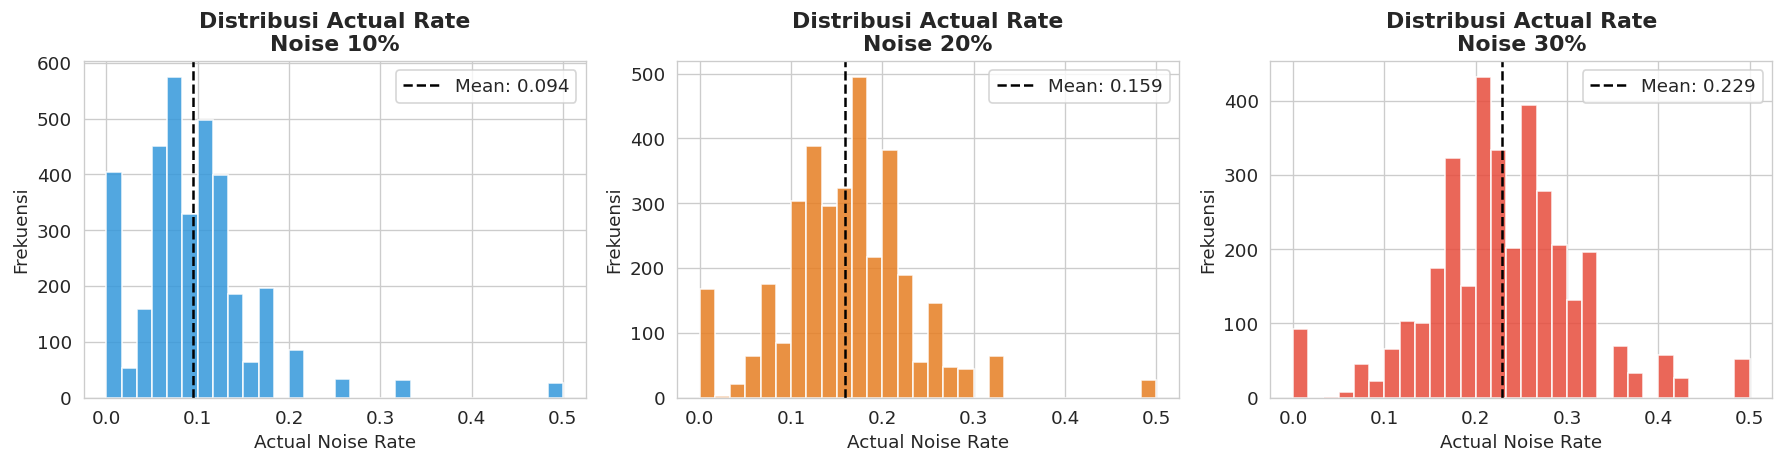

In [8]:
datasets = {
    'Clean (0%)'  : df_test_clean,
    'Noise 10%'   : df_test_n10,
    'Noise 20%'   : df_test_n20,
    'Noise 30%'   : df_test_n30,
}

print('=== STATISTIK ACTUAL NOISE RATE ===\n')
print(f'{"Dataset":<15} {"Mean Rate":>10} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 52)
for name, df_d in datasets.items():
    r = df_d['actual_rate']
    print(f'{name:<15} {r.mean():>10.4f} {r.std():>8.4f} {r.min():>8.4f} {r.max():>8.4f}')

# Visualisasi distribusi actual noise rate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
noisy_sets = [
    ('Noise 10%', df_test_n10, '#3498db'),
    ('Noise 20%', df_test_n20, '#e67e22'),
    ('Noise 30%', df_test_n30, '#e74c3c'),
]

for ax, (name, df_d, color) in zip(axes, noisy_sets):
    ax.hist(df_d['actual_rate'], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_d['actual_rate'].mean(), color='black', linestyle='--',
               label=f'Mean: {df_d["actual_rate"].mean():.3f}')
    ax.set_title(f'Distribusi Actual Rate\n{name}', fontweight='bold')
    ax.set_xlabel('Actual Noise Rate')
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_actual_noise_rate.png', bbox_inches='tight')
plt.show()

Analisis Distribusi Jenis Noise

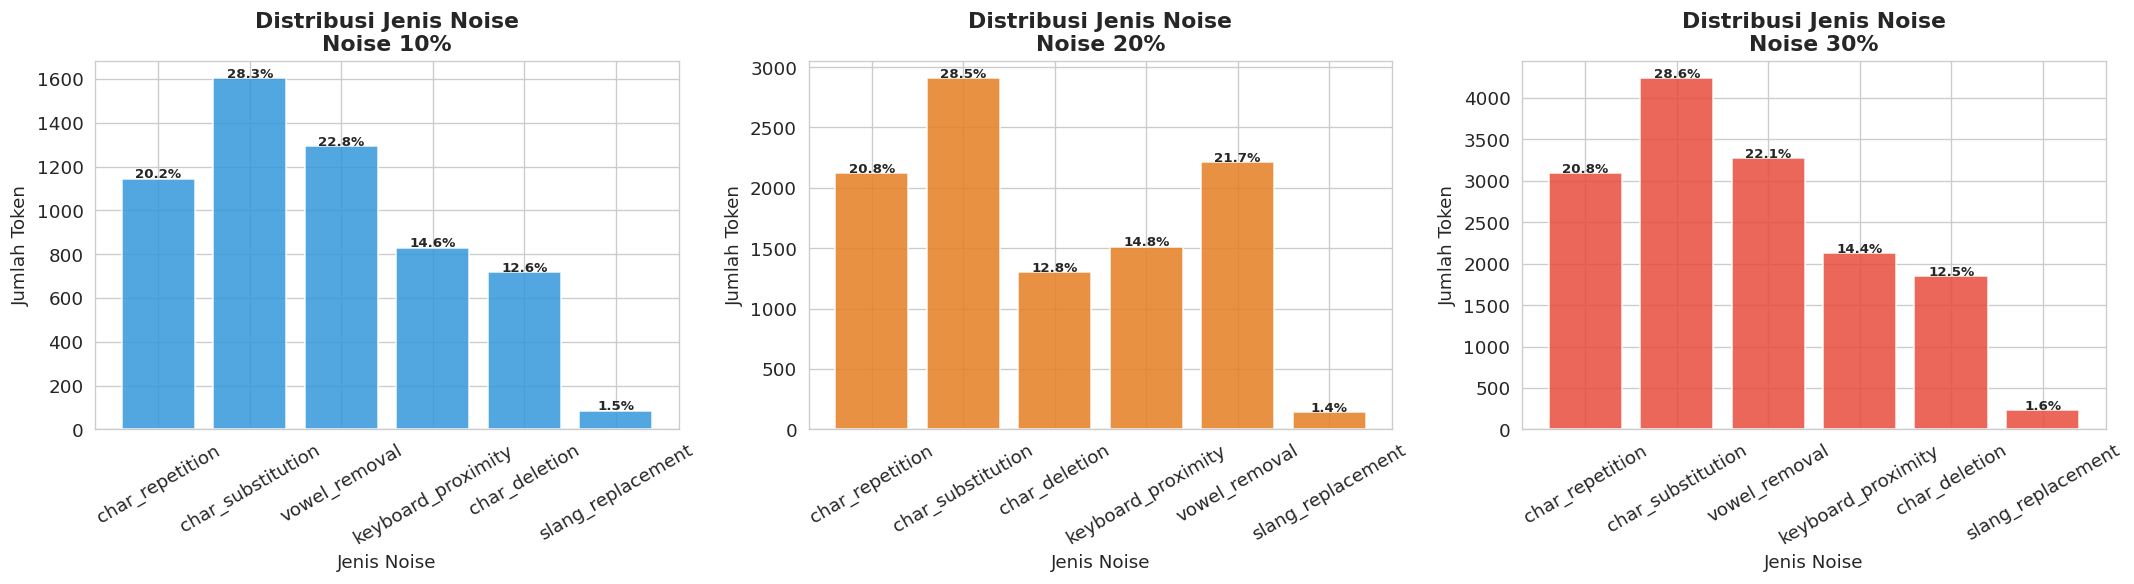

In [9]:
from ast import literal_eval

def aggregate_noise_types(df: pd.DataFrame) -> Dict[str, int]:
    """Agregat semua jenis noise dari kolom noise_types."""
    total = defaultdict(int)
    for row in df['noise_types']:
        try:
            d = literal_eval(row)
            for k, v in d.items():
                total[k] += v
        except Exception:
            pass
    return dict(total)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_bar = ['#3498db', '#e67e22', '#e74c3c']

for ax, (name, df_d, color) in zip(axes, noisy_sets):
    agg    = aggregate_noise_types(df_d)
    labels = list(agg.keys())
    values = list(agg.values())
    total  = sum(values)

    bars = ax.bar(labels, values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribusi Jenis Noise\n{name}', fontweight='bold')
    ax.set_xlabel('Jenis Noise')
    ax.set_ylabel('Jumlah Token')
    ax.tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, values):
        pct = val / total * 100 if total > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{pct:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_noise_type_distribution.png', bbox_inches='tight')
plt.show()

Visualisasi Contoh Noise per Level

In [10]:
print('=== CONTOH NOISE INJECTION PER LEVEL ===\n')

sample_idx = df_test.sample(5, random_state=SEED).index.tolist()

print(f'{"#":<3} {"Label":<10} {"Clean Text":<50} {"10%":<50} {"20%":<50} {"30%"}')
print('=' * 215)

for i, idx in enumerate(sample_idx):
    clean = df_test_clean.loc[df_test_clean.index == idx, 'tweet_clean'].values
    n10   = df_test_n10.iloc[df_test.index.get_loc(idx)]['tweet_noisy']
    n20   = df_test_n20.iloc[df_test.index.get_loc(idx)]['tweet_noisy']
    n30   = df_test_n30.iloc[df_test.index.get_loc(idx)]['tweet_noisy']
    label = LABEL_MAP[df_test.iloc[df_test.index.get_loc(idx)][LABEL_COLUMN]]

    clean_text = df_test.iloc[df_test.index.get_loc(idx)]['tweet_clean']
    print(f'{i+1:<3} [{label:<8}]')
    print(f'  CLEAN : {clean_text}')
    print(f'  10%   : {n10}')
    print(f'  20%   : {n20}')
    print(f'  30%   : {n30}')
    print()

=== CONTOH NOISE INJECTION PER LEVEL ===

#   Label      Clean Text                                         10%                                                20%                                                30%
1   [Positif ]
  CLEAN : berita beritaterkini beritajogja beritajakarta news newsupdate viral viraltiktok viraltwitter covid19 covid covid covidvaccine covid vaksinasi vaksinasinasional vaksin ppkmredakancovid19 ppkmlevelturun ppkmdiperpanjang ppkm
  10%   : berita beritaterini beritajogja beritajakarta news newsupdate viral viraltiktok viraltwitted covid19 covid covid covidvaccine covid vaksinasi vaksinasinasional vaksin ppkmredakancovid19 ppkmlevelturun ppkmdiperpanjang ppkm
  20%   : berita beritaterkini beritajogja beritajakarta news newsupdate viral viraltiktok vrltwttr covid19 covid cvd covidvaccine covid vaksinasi vaksinasinasional vaksin ppkmredakancovid19 ppkmlevelturun ppkmdiperpanjang ppkm
  30%   : berita brttrkni beritajogja beritajakarta news newsupdate viral vi

Verifikasi Integritas Data

In [11]:
print('=== VERIFIKASI INTEGRITAS TEST SETS ===\n')

all_ok = True

for name, path, df_d in [
    ('Clean',    TEST_CLEAN_PATH,    df_test_clean),
    ('Noise 10%', TEST_NOISE_10_PATH, df_test_n10),
    ('Noise 20%', TEST_NOISE_20_PATH, df_test_n20),
    ('Noise 30%', TEST_NOISE_30_PATH, df_test_n30),
]:
    # Load ulang dari disk
    df_loaded  = pd.read_csv(path)

    # Cek 1: jumlah baris konsisten
    row_ok     = len(df_loaded) == len(df_test)

    # Cek 2: label tidak berubah
    label_ok   = (df_loaded[LABEL_COLUMN].values == df_test[LABEL_COLUMN].values).all()

    # Cek 3: tidak ada null di kolom utama
    null_ok    = df_loaded[['tweet_noisy', LABEL_COLUMN]].isnull().sum().sum() == 0

    # Cek 4: file ada di disk
    file_ok    = os.path.exists(path)

    status     = '✅' if all([row_ok, label_ok, null_ok, file_ok]) else '❌'
    if not all([row_ok, label_ok, null_ok, file_ok]):
        all_ok = False

    print(f'{status} {name:<12} | rows={row_ok} | labels={label_ok} | no_null={null_ok} | file={file_ok}')
    print(f'     Path  : {path}')
    print(f'     Shape : {df_loaded.shape}\n')

if all_ok:
    print('🎉 Semua test set valid dan siap digunakan untuk evaluasi model!')
else:
    print('⚠️  Ada masalah pada salah satu test set. Periksa output di atas.')

=== VERIFIKASI INTEGRITAS TEST SETS ===

✅ Clean        | rows=True | labels=True | no_null=True | file=True
     Path  : /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_clean.csv
     Shape : (3495, 8)

✅ Noise 10%    | rows=True | labels=True | no_null=True | file=True
     Path  : /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_noise_10.csv
     Shape : (3495, 8)

✅ Noise 20%    | rows=True | labels=True | no_null=True | file=True
     Path  : /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_noise_20.csv
     Shape : (3495, 8)

✅ Noise 30%    | rows=True | labels=True | no_null=True | file=True
     Path  : /content/drive/MyDrive/sentiment-robustness-id/data/noisy/test_noise_30.csv
     Shape : (3495, 8)

🎉 Semua test set valid dan siap digunakan untuk evaluasi model!


Ekspor noise_injection.py ke src/

In [12]:
# ============================================================
# Simpan semua fungsi noise sebagai modul Python
# agar bisa diimport dari notebook lain jika diperlukan
# ============================================================

module_code = '''# =============================================================
# noise_injection.py — Noise Injection Engine
# Evaluasi Robustness Model Sentimen Bahasa Indonesia
# =============================================================

import random
import numpy as np
from collections import defaultdict
from typing import List, Tuple, Dict, Callable

VOWELS = set("aiueo")
REPETITION_CHARS = list("aiueoknrsh")
REPETITION_MIN   = 2
REPETITION_MAX   = 4

CHAR_SUBSTITUTION_MAP = {
    "a": ["4", "@", "q"], "e": ["3", "eh"], "i": ["1", "y", "!"],
    "o": ["0", "u"],      "u": ["v", "uw"], "s": ["z", "5"],
    "g": ["9", "q"],      "k": ["q", "c"],  "n": ["m", "ng"],
    "t": ["7", "th"],
}

SLANG_MAP = {
    "tidak": ["gak","ga","gk","nggak","enggak","ndak"],
    "kamu" : ["km","lo","elu","loe"],
    "saya" : ["gue","gw","aku","w"],
    "sangat": ["bgt","banget","poll","parah"],
    "dengan": ["dgn","ama","sama"],
    "yang"  : ["yg","yng"],
    "sudah" : ["udah","udh","dah"],
    "belum" : ["blm","blom","belom"],
    "karena": ["krn","karna","soalnya"],
    "mereka": ["mrk","mereka"],
    "juga"  : ["jg","jugak","pun"],
    "tapi"  : ["tp","tpi","tapii"],
    "untuk" : ["utk","buat","bwt"],
    "kalau" : ["klo","kalo","klw"],
    "bagus" : ["oke","ok","mantap","mantul","mantab"],
    "jelek" : ["parah","ancur","rusak","boo"],
    "bisa"  : ["bs","bsa","iso"],
    "mau"   : ["mo","mw","pengen"],
    "ada"   : ["ad","ade"],
    "apa"   : ["ap","apaan","apasih"],
}

KEYBOARD_PROXIMITY_MAP = {
    "q":["w","a"],       "w":["q","e","a","s"],   "e":["w","r","s","d"],
    "r":["e","t","d","f"],"t":["r","y","f","g"],  "y":["t","u","g","h"],
    "u":["y","i","h","j"],"i":["u","o","j","k"],  "o":["i","p","k","l"],
    "p":["o","l"],        "a":["q","w","s","z"],   "s":["a","w","e","d","z","x"],
    "d":["s","e","r","f","x","c"],"f":["d","r","t","g","c","v"],
    "g":["f","t","y","h","v","b"],"h":["g","y","u","j","b","n"],
    "j":["h","u","i","k","n","m"],"k":["j","i","o","l","m"],
    "l":["k","o","p"],    "z":["a","s","x"],       "x":["z","s","d","c"],
    "c":["x","d","f","v"],"v":["c","f","g","b"],   "b":["v","g","h","n"],
    "n":["b","h","j","m"],"m":["n","j","k"],
}

def apply_char_substitution(word):
    chars = list(word)
    candidates = [(i,c) for i,c in enumerate(chars) if c in CHAR_SUBSTITUTION_MAP]
    if not candidates: return word
    idx, char = random.choice(candidates)
    chars[idx] = random.choice(CHAR_SUBSTITUTION_MAP[char])
    return "".join(chars)

def apply_vowel_removal(word):
    if len(word) < 4: return word
    result = word[0]
    for char in word[1:-1]:
        if char not in VOWELS: result += char
    result += word[-1]
    return result if len(result) >= 2 else word

def apply_slang_replacement(word):
    return random.choice(SLANG_MAP[word]) if word in SLANG_MAP else word

def apply_char_repetition(word):
    if len(word) < 3: return word
    chars = list(word)
    candidates = [i for i,c in enumerate(chars[1:],start=1) if c in REPETITION_CHARS]
    if not candidates: return word
    idx = random.choice(candidates)
    chars[idx] = chars[idx] * random.randint(REPETITION_MIN, REPETITION_MAX)
    return "".join(chars)

def apply_keyboard_proximity(word):
    chars = list(word)
    candidates = [(i,c) for i,c in enumerate(chars) if c in KEYBOARD_PROXIMITY_MAP]
    if not candidates: return word
    idx, char = random.choice(candidates)
    chars[idx] = random.choice(KEYBOARD_PROXIMITY_MAP[char])
    return "".join(chars)

def apply_char_deletion(word):
    if len(word) < 4: return word
    idx = random.randint(1, len(word)-2)
    return word[:idx] + word[idx+1:]

NOISE_FUNCTIONS = [
    ("char_substitution",  apply_char_substitution,  0.20),
    ("vowel_removal",      apply_vowel_removal,       0.20),
    ("slang_replacement",  apply_slang_replacement,   0.25),
    ("char_repetition",    apply_char_repetition,     0.15),
    ("keyboard_proximity", apply_keyboard_proximity,  0.10),
    ("char_deletion",      apply_char_deletion,       0.10),
]
NOISE_NAMES   = [n for n,_,_ in NOISE_FUNCTIONS]
NOISE_WEIGHTS = [w for _,_,w in NOISE_FUNCTIONS]
NOISE_FUNCS   = [f for _,f,_ in NOISE_FUNCTIONS]

def inject_noise(text, noise_level, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    tokens   = text.split()
    n_tokens = len(tokens)
    if n_tokens == 0:
        return text, {"n_tokens": 0, "n_noised": 0, "noise_types": {}}
    n_to_noise  = max(1, int(np.ceil(n_tokens * noise_level)))
    noise_idxs  = sorted(random.sample(range(n_tokens), min(n_to_noise, n_tokens)))
    noisy_tokens = tokens.copy()
    noise_log    = defaultdict(int)
    for idx in noise_idxs:
        original    = tokens[idx]
        noise_func  = random.choices(NOISE_FUNCS, weights=NOISE_WEIGHTS, k=1)[0]
        func_name   = NOISE_NAMES[NOISE_FUNCS.index(noise_func)]
        noisy       = noise_func(original)
        if noisy != original:
            noisy_tokens[idx] = noisy
            noise_log[func_name] += 1
    stats = {
        "n_tokens"   : n_tokens,
        "n_noised"   : sum(noise_log.values()),
        "actual_rate": sum(noise_log.values()) / n_tokens if n_tokens > 0 else 0,
        "noise_types": dict(noise_log),
    }
    return " ".join(noisy_tokens), stats
'''

module_path = f'{ROOT}/src/noise_injection.py'
with open(module_path, 'w') as f:
    f.write(module_code)

print(f'✅ noise_injection.py disimpan di: {module_path}')

✅ noise_injection.py disimpan di: /content/drive/MyDrive/sentiment-robustness-id/src/noise_injection.py


Ringkasan Noise Injection

In [13]:
print('=' * 55)
print('     RINGKASAN NOISE INJECTION ENGINE')
print('=' * 55)
print(f'''
🔧 JENIS NOISE (6 kategori)
  1. Char Substitution   — bagus → baguz       (bobot 20%)
  2. Vowel Removal       — mantap → mntp        (bobot 20%)
  3. Slang Replacement   — tidak → gak          (bobot 25%)
  4. Char Repetition     — parah → parahhh      (bobot 15%)
  5. Keyboard Proximity  — makan → majan        (bobot 10%)
  6. Char Deletion       — sekarang → sekrang   (bobot 10%)

📂 OUTPUT TEST SETS
  test_clean.csv      → {len(df_test_clean):,} baris (noise 0%)
  test_noise_10.csv   → {len(df_test_n10):,} baris (noise 10%)
  test_noise_20.csv   → {len(df_test_n20):,} baris (noise 20%)
  test_noise_30.csv   → {len(df_test_n30):,} baris (noise 30%)

🔒 INTEGRITAS
  Label tidak berubah di semua versi ✅
  Seed terkontrol per baris ✅
  Modul disimpan di src/noise_injection.py ✅

✅ Lanjut ke 04_Baseline_Model.ipynb
  → Aktifkan GPU sebelum membuka notebook 04
''')
print('=' * 55)

     RINGKASAN NOISE INJECTION ENGINE

🔧 JENIS NOISE (6 kategori)
  1. Char Substitution   — bagus → baguz       (bobot 20%)
  2. Vowel Removal       — mantap → mntp        (bobot 20%)
  3. Slang Replacement   — tidak → gak          (bobot 25%)
  4. Char Repetition     — parah → parahhh      (bobot 15%)
  5. Keyboard Proximity  — makan → majan        (bobot 10%)
  6. Char Deletion       — sekarang → sekrang   (bobot 10%)

📂 OUTPUT TEST SETS
  test_clean.csv      → 3,495 baris (noise 0%)
  test_noise_10.csv   → 3,495 baris (noise 10%)
  test_noise_20.csv   → 3,495 baris (noise 20%)
  test_noise_30.csv   → 3,495 baris (noise 30%)

🔒 INTEGRITAS
  Label tidak berubah di semua versi ✅
  Seed terkontrol per baris ✅
  Modul disimpan di src/noise_injection.py ✅

✅ Lanjut ke 04_Baseline_Model.ipynb
  → Aktifkan GPU sebelum membuka notebook 04

